# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Moho Goswami

**ID**: mg2297

> **Due Date**
>
> Thursday, 10/23/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\mohog\hw3-mohogos`


In [4]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

Given constants
* U = 6 km/day
* k_a = 0.55/day
* k_c = 0.35/day
* k_n = 0.25/day
* C_s = 10 mg/L
* x = 50 km

Analytical Solution Equation (ignoring photosynthesis, respiration, and benthal uptake)
\begin{align*}
C(x) &= Cs(1-a_1) + C0a_1 - B0a_2 - N0a_3
\end{align*}

Determine concentration at x = 0 km
\begin{align*}
a_1 &= e^{-\frac{0.55 \cdot 0}{6}} = e^0 = 1 \\
a_2 &= \left( \frac{0.35}{0.55 - 0.35} \right) \left( e^{-\frac{0.35 \cdot 0}{6}} - e^{-\frac{0.55 \cdot 0}{6}} \right) \\
&= 1.75 \cdot (1 - 1) = 0 \\
a_3 &= \left( \frac{0.25}{0.55 - 0.25} \right) \left( e^{-\frac{0.25 \cdot 0}{6}} - e^{-\frac{0.55 \cdot 0}{6}} \right) \\
&= 0.833 \cdot (1 - 1) = 0 \\
\\
C(x) &= 10(1 - a_1) + C_0 a_1 - B_0 a_2 - N_0 a_3 \\
C(x=0) &= 10(1 - 1) + C_0(1) - B_0(0) - N_0(0) = C_0
\end{align*}

Determine values of C0, B0, and N0
* Total flow: 100,000 m3/day + 10,000 m3/day = 110,000 m3/day = 110000000 L/day
* Ratio: river inflow = 10/11, waste stream 1 = 1/11
\begin{align*}
C_0 &= (7.5~\text{mg/L}) \cdot \left( \frac{10}{11} \right) + (5~\text{mg/L}) \cdot \left( \frac{1}{11} \right) \\
&= 7.27~\text{mg/L} \\
B_0 &= (5~\text{mg/L}) \cdot \left( \frac{10}{11} \right) + (50~\text{mg/L}) \cdot \left( \frac{1}{11} \right) \\
&= 9.09~\text{mg/L} \\
N_0 &= (5~\text{mg/L}) \cdot \left( \frac{10}{11} \right) + (35~\text{mg/L}) \cdot \left( \frac{1}{11} \right) \\
&= 7.72~\text{mg/L}
\end{align*}

Total dissolved oxygen concentration, x = 0
\begin{align*}
C(x=0) &= 7.27
\end{align*}

Determine a values and DO concentration at x = 15 km
\begin{align*}
a_1 &= e^{-\frac{0.55 \cdot 15}{6}} = 0.253 \\
a_2 &= \left( \frac{0.35}{0.55 - 0.35} \right) \left( e^{-\frac{0.35 \cdot 15}{6}} - e^{-\frac{0.55 \cdot 15}{6}} \right) \\
&= 1.75 \cdot (0.164) = 0.287 \\
a_3 &= \left( \frac{0.25}{0.55 - 0.25} \right) \left( e^{-\frac{0.25 \cdot 15}{6}} - e^{-\frac{0.55 \cdot 15}{6}} \right) \\
&= 0.833 \cdot (0.2824) = 0.235 \\
C(x) &= 10(1 - 0.253) + C_0(0.253) - B_0(0.287) - N_0(0.235) \\
C(x=15) &= 10(0.747) + C_0(0.253) - B_0(0.287) - N_0(0.235) \\
\end{align*}

Apply previous initial concentrations
\begin{align*}
C(x=15) &= 10(0.747) + 7.27(0.253) - 9.09(0.287) - 7.72(0.235) \\
C(x=15) &= 4.89
\end{align*}

Account for decay of CBOD and NBOD before mixing at 15 m
\begin{align*}
B_0 &= 9.09 \cdot e^{-\frac{0.35 \cdot 15}{6}} \\
&= 3.79 \\
N_0 &= 7.72 \cdot e^{-\frac{0.25 \cdot 15}{6}} \\
&= 4.13
\end{align*}


Detemine values of C0, B0, and N0 after mixing with waste stream 2
* Total flow: 110,000 m3/day + 15,000 m3/day = 125,000 m3/day
* Ratio: river + stream 1 = 22/25, stream 2 = 3/25

\begin{align*}
C_0 &= (4.89~\text{mg/L}) \cdot \left( \frac{22}{25} \right) + (5~\text{mg/L}) \cdot \left( \frac{3}{25} \right) \\
&= 4.90~\text{mg/L} \\
B_0 &= (3.79~\text{mg/L}) \cdot \left( \frac{22}{25} \right) + (45~\text{mg/L}) \cdot \left( \frac{3}{25} \right) \\
&= 8.735~\text{mg/L} \\
N_0 &= (4.13~\text{mg/L}) \cdot \left( \frac{22}{25} \right) + (35~\text{mg/L}) \cdot \left( \frac{3}{25} \right) \\
&= 7.834~\text{mg/L}
\end{align*}

Total dissolved oxygen concentration, x = 15
\begin{align*}
C(x=15) &= 10(0.747) + 4.90(0.253) - 8.735(0.287) - 7.834(0.235) \\
C(x=15) &= 4.36
\end{align*}

| Parameter | \( x = 0 km \) | \( x = 15 km \) |
|:----------:|:----------------:|:----------------:|
| a_1 | 1.000 | 0.253 |
| a_2  | 0.000 | 0.287 |
| a_3  | 0.000 | 0.235 |
| C_0  | 7.27 | 4.90 |
| B_0  | 9.09 | 8.735 |
| N_0  | 7.72 | 7.834 |
| C(x) | 7.27 | 4.36 |

Minimum DO Concentration: 3.7571658426584706 mg/L
Occurs at: 22.5 km downstream


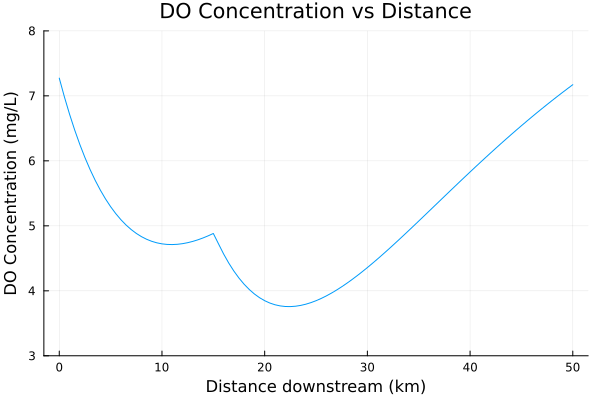

In [ ]:
# Constants
U = 6.0            # km/day
k_a = 0.55         # /day
k_c = 0.35         # /day
k_n = 0.25         # /day
C_s = 10.0         # mg/L
Δx = 0.5           # step size

# Flows (m³/day)
Q_r = 100_000.0
Q1  = 10_000.0
Q2  = 15_000.0

Q_m1 = Q_r + Q1 
Q_total = Q_m1 + Q2

# Inflow concentrations
C_r = 7.5
B_r = 5.0
N_r = 5.0

# Waste stream 1
C1_ws = 5.0
B1_ws = 50.0
N1_ws = 35.0

# Waste stream 2
C2_ws = 5.0
B2_ws = 45.0
N2_ws = 35.0

# Mixing after first waste stream
C0_1 = (Q_r*C_r + Q1*C1_ws) / Q_m1
B0_1 = (Q_r*B_r + Q1*B1_ws) / Q_m1
N0_1 = (Q_r*N_r + Q1*N1_ws) / Q_m1

# Recalibrate values at 15 m before mixing
t = 15 / U
a1_15 = 0.253
a2_15 = 0.287
a3_15 = 0.235
C_15 = C_s * (1 - a1_15) + C0_1 * a1_15 - B0_1 * a2_15 - N0_1 * a3_15
B_15 = B0_1 * exp(-k_c * t)
N_15 = N0_1 * exp(-k_n * t)
C_15

# Mixing mixed stream with second waste stream at 15 m
C0_2 = (Q_m1*C_15 + Q2*C2_ws) / Q_total
B0_2 = (Q_m1*B_15 + Q2*B2_ws) / Q_total
N0_2 = (Q_m1*N_15 + Q2*N2_ws) / Q_total

function do_analytic(L, C0, B0, N0, k_a, k_n, k_c, C_s, U)
    x_vals = 0:0.5:L
    C_vals = Float64[]

    for x in x_vals
        a1 = exp(-k_a * x / U)
        a2 = (k_c / (k_a - k_c)) * (exp(-k_c * x / U) - exp(-k_a * x / U))
        a3 = (k_n / (k_a - k_n)) * (exp(-k_n * x / U) - exp(-k_a * x / U))
        C = C_s * (1 - a1) + C0 * a1 - B0 * a2 - N0 * a3
        push!(C_vals, C)
    end

    return x_vals, C_vals
end

L1 = 15.0
L2 = 35.0
x1, C1 = do_analytic(L1, C0_1, B0_1, N0_1, k_a, k_n, k_c, C_s, U)
x2_local, C2 = do_analytic(L2, C0_2, B0_2, N0_2, k_a, k_n, k_c, C_s, U)

DO_distance_analytic = vcat(x1, x2[2:end])
DO_concentration_analytic = vcat(C1, C2[2:end])

min_DO = minimum(DO_concentration_analytic)
min_index = argmin(DO_concentration_analytic)
min_distance = DO_distance_analytic[min_index]

println("Minimum DO Concentration: $(min_DO) mg/L")
println("Occurs at: $(min_distance) km downstream")

plot(DO_distance_analytic, DO_concentration_analytic, xlabel = "Distance downstream (km)", ylabel = "DO Concentration (mg/L)", title = "DO Concentration vs Distance", legend = false, ylim=(3,8))

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

Minimum DO Concentration: 3.691734482221712 mg/L
Occurs at: 22.5 km downstream


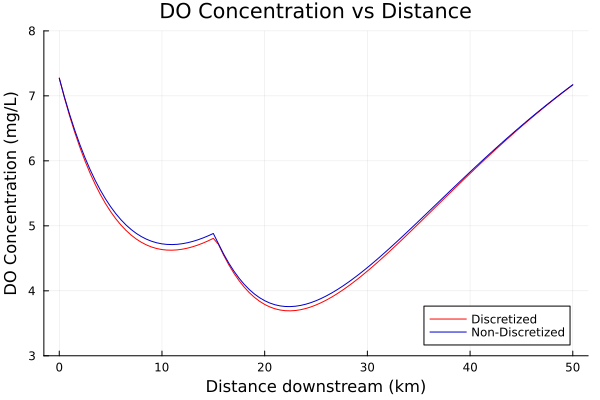

In [43]:
# Constants
U = 6.0            # km/day
k_a = 0.55         # /day
k_c = 0.35         # /day
k_n = 0.25         # /day
C_s = 10.0         # mg/L
Δx = 0.5           # step size

# Flows (m³/day)
Q_r = 100_000.0
Q1  = 10_000.0
Q2  = 15_000.0

Q_m1 = Q_r + Q1 
Q_total = Q_m1 + Q2

# Inflow concentrations
C_r = 7.5
B_r = 5.0
N_r = 5.0

# Waste stream 1
C1_ws = 5.0
B1_ws = 50.0
N1_ws = 35.0

# Waste stream 2
C2_ws = 5.0
B2_ws = 45.0
N2_ws = 35.0

# Mixing after first waste stream
C0_1 = (Q_r*C_r + Q1*C1_ws) / Q_m1
B0_1 = (Q_r*B_r + Q1*B1_ws) / Q_m1
N0_1 = (Q_r*N_r + Q1*N1_ws) / Q_m1

# Recalibrate values at 15 m before mixing
t = 15 / U
a1_15 = 0.253
a2_15 = 0.287
a3_15 = 0.235
C_15 = C_s * (1 - a1_15) + C0_1 * a1_15 - B0_1 * a2_15 - N0_1 * a3_15
B_15 = B0_1 * exp(-k_c * t)
N_15 = N0_1 * exp(-k_n * t)
C_15

# Mixing decayed stream with second waste stream only
C0_2 = (Q_m1*C_15 + Q2*C2_ws) / Q_total
B0_2 = (Q_m1*B_15 + Q2*B2_ws) / Q_total
N0_2 = (Q_m1*N_15 + Q2*N2_ws) / Q_total

# Defining distance range and DO concentration array
DO_distance_discretized = 0:0.5:50
DO_concentration_discretized = Float64[]

# Defining function
function do_numerical(L, Δx, CO, BO, NO, ka, kn, kc, Cs, U)
    n = Int(L / Δx)
    C = zeros(n + 1)
    B = zeros(n + 1)
    N = zeros(n + 1)
    C[1] = CO
    B[1] = BO
    N[1] = NO
    for i = 1:n
        B[i+1] = B[i] * exp(-kc * Δx / U)
        N[i+1] = N[i] * exp(-kn * Δx / U)
        C[i+1] = C[i] + (Δx / U) * (ka * (Cs - C[i]) - kc * B[i] - kn * N[i])
    end
    return (C, B, N)
end

L1 = 15.0
C1, B1, N1 = do_numerical(L1, Δx, C0_1, B0_1, N0_1, k_a, k_n, k_c, C_s, U)
L2 = 35.0
C2, B2, N2 = do_numerical(L2, Δx, C0_2, B0_2, N0_2, k_a, k_n, k_c, C_s, U)
DO_concentration_discretized = vcat(C1, C2[2:end])

min_DO = minimum(DO_concentration_discretized)
min_index = argmin(DO_concentration_discretized)
min_distance = DO_distance_discretized[min_index]

println("Minimum DO Concentration: $(min_DO) mg/L")
println("Occurs at: $(min_distance) km downstream")
plot(DO_distance_discretized, DO_concentration_discretized, xlabel="Distance downstream (km)", ylabel="DO Concentration (mg/L)", title="DO Concentration vs Distance", legend=true, linecolor=[:red], label="Discretized",ylim=(3,8))
plot!(DO_distance_analytic, DO_concentration_analytic, legend = true, linecolor=[:mediumblue], label="Non-Discretized")

Although the discretized solution identifies the minimum DO concentration as being at the same location as in the non-discretized solution - 22.5 km downstream - the minimum value has slightly decreased from 3.75 to 3.69 mg/L. The discretized solution introduces greater complexity in the calculations by making the DO concentration, CBOD, and NBOD be time-varying with every increase in the step size of 0.5 km. In contrast, the analytical solution recalibrated the values at x = 15 as that was the second mixing point but did not consistently adjust these values.

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

Analytic model:
* C(x) = Cs(1-a1) + C0a1 - B0a2 - N0a3

Applying 5% margin of safety to compliance minimum:
* C(x) >= 4 * 1.05 = 4.2 mg/L

Waste 1 treated, waste 2 untreated

Waste 2 treated, waste 1 untreated


### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

* insert explanation here after finishing 1.3
* In a real-world context, other helpful information would be monetary costs of water treatment and budget constraints.

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

In [19]:
Random.seed!(1)

TaskLocalRNG()

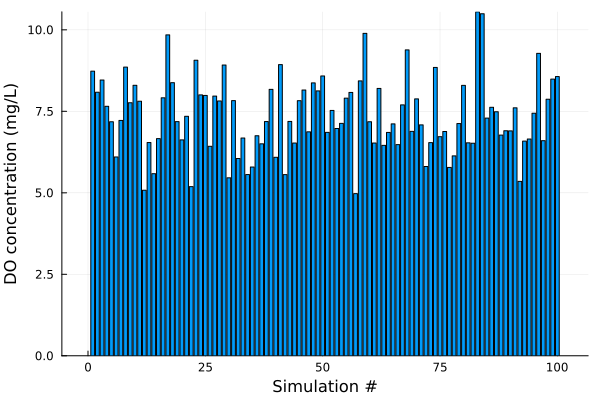

In [36]:
# Apply LogNormal probability distribution for DO concentration of river inflow
C_river = 7.5 #mg/L

ln_distribution = LogNormal(2.0, 0.15)
ln_DO_river = rand(ln_distribution,100)

bar(ln_DO_river, legend=:false, bins=100)
ylabel!("DO concentration (mg/L)")
xlabel!("Simulation #")

In [38]:
# Output Monte Carlo estimates
mean_distribution = mean(ln_DO_river)
println("  Mean Monte Carlo estimate of DO concentration at river inflow: $(round(mean_distribution; digits=2))")

  Mean Monte Carlo estimate of DO concentration at river inflow: 7.36


In [ ]:
# Defining constants
U = 6 #km/day
k_a = 0.55 #/day
k_c = 0.35 #/day
k_n = 0.25 #/day
C_s = 10 #mg/L

B0_1 = 9.09 #mg/L
N0_1 = 7.72 #mg/L

B0_2 = 13.40 #mg/L
N0_2 = 11.00 #mg/L

# Values relevant to how DO concentration at river inflow affects subsequent values
C0 = (7.5 mg/L) * (10/11) + (5 mg/L) * (1/11) = 7.27 mg/L
C(x=15) = 10(0.747) + 7.27(0.253) - 9.09(0.287) - 7.72(0.235)
C(x=15) = 4.89
Detemine values of C0, B0, and N0
Total flow: 110,000 m3/day + 15,000 m3/day = 125,000 m3/day
Ratio: river + stream 1 = 22/25, stream 2 = 3/25
C0 = (4.89 mg/L) * (22/25) + (5 mg/L) * (3/25) = 4.90
Total dissolved oxygen concentration
C(x=15) = 10(0.747) + 4.90(0.253) - 13.40(0.287) - 11.00(0.235)
C(x=15) = 2.28

# Defining function
distance = 0:0.5:50
DO_concentration = []

for d in distance
    a1 = exp(-k_a*d/U)
    a2 = (k_c/(k_a-k_c))*(exp(-k_c*d/U)-exp(-k_a*d/U))
    a3 = (k_n/(k_a-k_n))*(exp(-k_n*d/U)-exp(-k_a*d/U))
    if d <= 15
        C = C_s*(1-a1) + C0_1*a1 - B0_1*a2 - N0_1*a3
    else
        C = C_s*(1-a1) + C0_2*a1 - B0_2*a2 - N0_2*a3
    end
    push!(DO_concentration, C)
end

Base.Meta.ParseError: ParseError:
# Error @ c:\Users\mohog\hw3-mohogos\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:31:11
# Values relevant to how DO concentration at river inflow affects subsequent values
C0 = (7.5 mg/L) * (10/11) + (5 mg/L) * (1/11) = 7.27 mg/L
#         └──┘ ── Expected `)`

## References

List any external references consulted, including classmates.

* TA office hours